In [1]:
import numpy as np
import pandas as pd
import os

In [40]:
df = pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]],columns=["cgpa","profile_score","lpa"])

In [41]:
df.head()

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


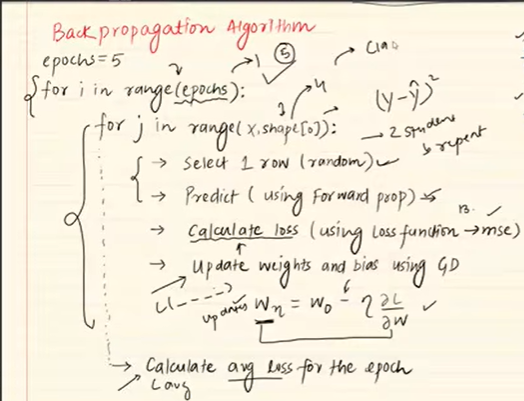

In [42]:
def initialize_parameters(layer_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims)
    
    for l in range(1,L):
        
        parameters['W' + str(l)] = np.ones((layer_dims[l-1],layer_dims[l]))*0.1
        parameters['b' + str(l)] = np.zeros((layer_dims[l],1))
    
    return parameters

In [43]:
def linear_forward(A_prev,W,b):
    Z = np.dot(W.T,A_prev) + b
    return Z

In [44]:
def L_layer_forward(X,parameters):
    A = X
    L = len(parameters)//2
    
    for l in range(1,L+1):
        A_prev = A
        W1 = parameters['W' + str(l)] 
        b1 = parameters['b' + str(l)]
        # print("A" + str(l-1) +": ",A_prev) 
        # print("W" + str(l) +": ",W1) 
        # print("b" + str(l) +": ",b1)
        # print("--"*20)
        
        A = linear_forward(A_prev,W1,b1)
        # print("A"+str(l)+": ",A)
        # print("--"*20) 
    
    return A,A_prev

In [45]:
X = df[['cgpa',"profile_score"]].values[0].reshape(2,1)
y = df[['lpa']].values[0][0]
parameters = initialize_parameters([2,2,1])
y_hat,A1 = L_layer_forward(X, parameters)

In [46]:
y_hat

array([[0.32]])

In [47]:
(y-0.32)**2 #loss for the first student 

13.5424

In [48]:
#Backpropagation (all 9 steps(gradients) are written)
def update_parameters(parameters,y,y_hat,A1,X):
  parameters['W2'][0][0] = parameters['W2'][0][0] + (0.001 * 2 * (y - y_hat)*A1[0][0])
  parameters['W2'][1][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat)*A1[1][0])
  parameters['b2'][0][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat))

  parameters['W1'][0][0] = parameters['W1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[0][0])
  parameters['W1'][0][1] = parameters['W1'][0][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[1][0])
  parameters['b1'][0][0] = parameters['b1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0])

  parameters['W1'][1][0] = parameters['W1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[0][0])
  parameters['W1'][1][1] = parameters['W1'][1][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[1][0])
  parameters['b1'][1][0] = parameters['b1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]) 

In [49]:
X = df[['cgpa', 'profile_score']].values[0].reshape(2,1) # Shape(no of features, no. of training example)
y = df[['lpa']].values[0][0]

parameters = initialize_parameters([2,2,1])

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

{'W1': array([[0.10658137, 0.10658137],
        [0.10658137, 0.10658137]]),
 'b1': array([[0.00082267],
        [0.00082267]]),
 'W2': array([[0.111776],
        [0.111776]]),
 'b2': array([[0.119136]])}

In [50]:
# epochs implementation

parameters = initialize_parameters([2,2,1])
epochs = 5

for i in range(epochs):

  Loss = []

  for j in range(df.shape[0]):

    X = df[['cgpa', 'profile_score']].values[j].reshape(2,1)
    y = df[['lpa']].values[j][0]

    y_hat,A1 = L_layer_forward(X,parameters)
    y_hat = y_hat[0][0]

    update_parameters(parameters,y,y_hat,A1,X)

    Loss.append((y-y_hat)**2)

  print('Epoch - ',i+1,'Loss - ',np.array(Loss).mean())

parameters

Epoch -  1 Loss -  25.321744156025517
Epoch -  2 Loss -  18.320004165722047
Epoch -  3 Loss -  9.473661050729625
Epoch -  4 Loss -  3.252093863403161
Epoch -  5 Loss -  1.3407132589299964


{'W1': array([[0.26507636, 0.38558861],
        [0.27800387, 0.40980287]]),
 'b1': array([[0.02749056],
        [0.02974394]]),
 'W2': array([[0.41165744],
        [0.48302736]]),
 'b2': array([[0.48646246]])}

In [64]:
df = pd.DataFrame({
    'feature1': [8.0, 7.5, 9.0],
    'feature2': [100, 90, 115],
    'lpa': [6.0, 5.0, 8.5] # The target
})

In [65]:
import tensorflow as tf

In [66]:
model= tf.keras.Sequential([
    tf.keras.layers.Dense(2,activation='linear',input_dim=2),
    tf.keras.layers.Dense(1,activation='linear')
])

C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.get_weights()

[array([[ 0.7627193, -0.7992794],
        [-0.7526735, -0.8764012]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.2826047],
        [ 0.9697815]], dtype=float32),
 array([0.], dtype=float32)]

In [69]:
new_weights = [np.array([[0.1,0.1],[0.1,0.1]],dtype=np.float32),
               np.array([0.,0.],dtype=np.float32),
               np.array([[0.1],[0.1]],dtype=np.float32),
               np.array([0.],dtype=np.float32)]

In [70]:
model.set_weights(new_weights)

In [71]:
model.get_weights()

[array([[0.1, 0.1],
        [0.1, 0.1]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.1],
        [0.1]], dtype=float32),
 array([0.], dtype=float32)]

In [72]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss="mse",optimizer=optimizer)

In [73]:
X = df.iloc[:, 0:-1].values.astype(np.float32)
y = df['lpa'].values.astype(np.float32).reshape(-1, 1)

In [74]:
model.fit(X,y,epochs=75,verbose=1)

Epoch 1/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 20.0962
Epoch 2/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 19.6970
Epoch 3/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 19.2982
Epoch 4/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 18.8998
Epoch 5/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 18.5019
Epoch 6/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 18.1048
Epoch 7/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 17.7086
Epoch 8/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 17.3134
Epoch 9/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 16.9194
Epoch 10/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 16.5267
Epoch 11/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 16.1355
Epoch 12/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 15.7459
Epoch 13/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 15.3582
Epoch 14/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 14.9725
Epoch 15/75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 14.5890
Epoch 16/75
1/